In [68]:
import sys
import torch

print(sys.version)
print('Colab')
print(torch.cuda.is_available())

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Colab
True


In [69]:
!nvidia-smi

Fri Jul 31 02:07:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             27W /   70W |     771MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [70]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms

from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [71]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [72]:
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

trian_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=(MNIST_MEAN), std=(MNIST_STD))
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(MNIST_MEAN), std=(MNIST_STD))
])

full_train_dataset_aug = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=trian_transform
)
full_train_dataset_eval = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=eval_transform
)
test_dataset= datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=eval_transform
)

print(f'전체 학습 데이터 수: {len(full_train_dataset_aug)}')
print(f'전체 검증 데이터 수: {len(full_train_dataset_eval)}')
print(f'전체 테스트 데이터 수: {len(test_dataset)}')

전체 학습 데이터 수: 60000
전체 검증 데이터 수: 60000
전체 테스트 데이터 수: 10000


In [73]:
valid_size = 10000
train_size = len(full_train_dataset_aug) - valid_size

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(full_train_dataset_aug), generator=generator)

train_indices = indices[:train_size]
valid_indices = indices[train_size:]

train_dataset = Subset(full_train_dataset_aug, train_indices)
valid_dataset = Subset(full_train_dataset_eval, valid_indices)

print(f'학습 데이터 수: {len(train_dataset)}, 검증 데이터 수: {len(valid_dataset)}, 테스트 데이터 수: {len(test_dataset)}')

학습 데이터 수: 50000, 검증 데이터 수: 10000, 테스트 데이터 수: 10000


In [74]:
class_names = [str(i) for i in range(10)]

train_labels = full_train_dataset_eval.targets[train_indices].numpy()
valid_labels = full_train_dataset_eval.targets[valid_indices].numpy()
test_labels = test_dataset.targets.numpy()

label_df = pd.DataFrame({
    'train': pd.Series(train_labels).value_counts().sort_index(),
    'valid': pd.Series(valid_labels).value_counts().sort_index(),
    'test': pd.Series(test_labels).value_counts().sort_index(),
})
label_df

,train,valid,test
0,4923,1000,980
1,5613,1129,1135
2,4958,1000,1032
3,5093,1038,1010
4,4863,979,982
5,4546,875,892
6,4933,985,958
7,5204,1061,1028
8,4882,969,974
9,4985,964,1009


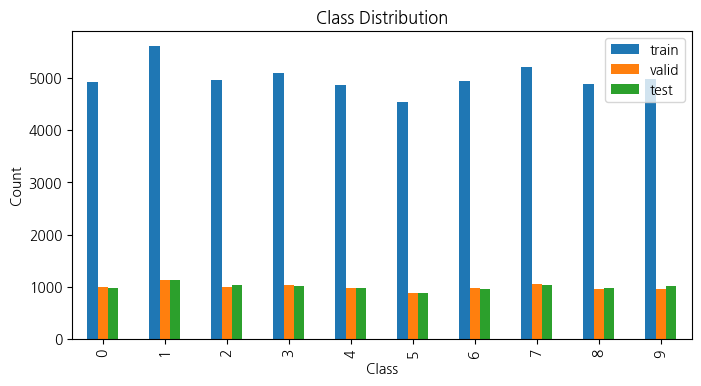

In [75]:
label_df.plot(kind='bar', figsize=(8, 4))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [76]:
BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([1024, 1, 28, 28]) torch.Size([1024])


In [77]:
import os

os.cpu_count()

2

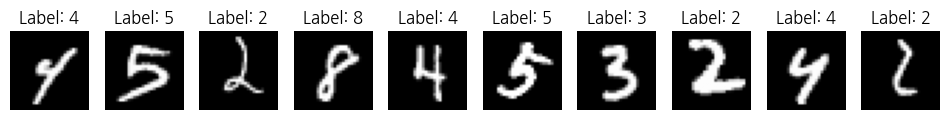

In [78]:
def denormalize(image_tensor):
    return image_tensor * MNIST_STD + MNIST_MEAN

def show_images(dataset, n=10):
    plt.figure(figsize=(12, 2))

    for i in range(n):
        image, label = dataset[i]
        image = denormalize(image).squeeze(0)

        plt.subplot(1, n, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')

    plt.show()

show_images(valid_dataset, 10)

In [79]:
class MNISTCNN(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(dropout_rate),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(dropout_rate)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNISTCNN().to(device)
model

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): SiLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): SiLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [80]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [81]:
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def __call__(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
                key: value.detach().cpu().clone() for key, value in model.state_dict().items()
            }

            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [82]:
def train_one_epoch(model, data_loader, criterion, optimizer, device, max_norm=1.0):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in tqdm(data_loader, desc='Train', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_count += batch_size

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    
    return avg_loss, avg_acc

In [83]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Evaluate', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_count += batch_size

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    
    return avg_loss, avg_acc

In [84]:
EPOCH = 10

early_stopping = EarlyStopping(patience=4, min_delta=0.0001)
history = []

for epoch in range(EPOCH):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, max_norm=1.0)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'valid_loss': valid_loss,
        'valid_acc': valid_acc,
        'lr': current_lr
    })

    print(
        f'Epoch: {epoch + 1}\n',
        f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}\n',
        f'Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}\n',
        f'Learning Rate: {current_lr}'
    )

    if early_stopping(valid_loss, model):
        print('Run Early_Stopping')
        break
    
early_stopping.restore_best_weights(model)

Train:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1
 Train Loss: 0.8565 | Train Acc: 0.8368
 Valid Loss: 0.5018 | Valid Acc: 0.9420
 Learning Rate: 0.001


Train:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/10 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 9
 Train Loss: 0.4013 | Train Acc: 0.9759
 Valid Loss: 0.3589 | Valid Acc: 0.9863
 Learning Rate: 0.001


Train:   0%|          | 0/49 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 10
 Train Loss: 0.3963 | Train Acc: 0.9778
 Valid Loss: 0.3584 | Valid Acc: 0.9874
 Learning Rate: 0.001


In [85]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,valid_loss,valid_acc,lr
0,1,0.856469,0.83684,0.501771,0.9420,0.001
1,2,0.496218,0.94734,0.411281,0.9698,0.001
2,3,0.452686,0.96084,0.385343,0.9790,0.001
3,4,0.437113,0.96536,0.376351,0.9813,0.001
4,5,0.425031,0.96884,0.375247,0.9818,0.001
5,6,0.415786,0.97230,0.366610,0.9844,0.001
6,7,0.411379,0.97364,0.363598,0.9861,0.001
7,8,0.406014,0.97452,0.361056,0.9859,0.001
8,9,0.401306,0.97586,0.358941,0.9863,0.001
9,10,0.396307,0.97782,0.358433,0.9874,0.001


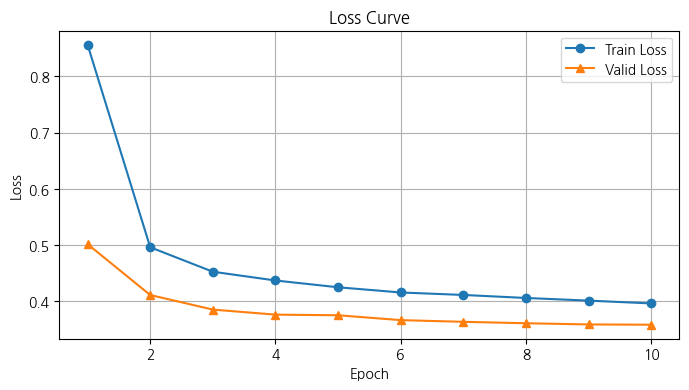

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], marker='^', label='Valid Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

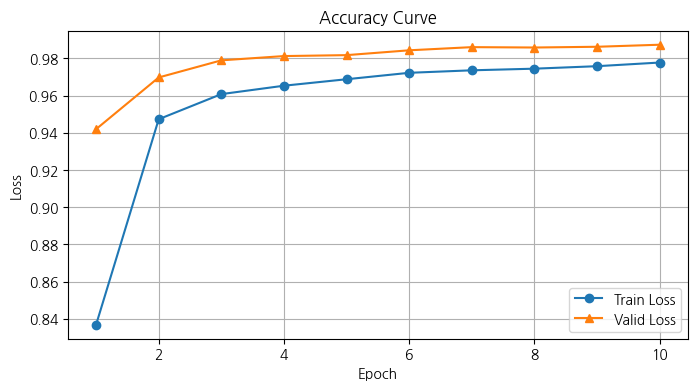

In [87]:
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_acc'], marker='o', label='Train Loss')
plt.plot(history_df['epoch'], history_df['valid_acc'], marker='^', label='Valid Loss')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [88]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

Evaluate:   0%|          | 0/10 [00:00<?, ?it/s]

Test Loss: 0.3542, Test Acc: 0.9888


In [89]:
def get_predictions(model, dataloader, device):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Get Predictions'):
            images = images.to(device)
            outputs = model(images)


            probabilities = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1) 

            y_true.append(labels.numpy())
            y_prob.append(probabilities.cpu().numpy())
            y_pred.append(predictions.cpu().numpy())
    
    return np.concatenate(y_true), np.concatenate(y_prob), np.concatenate(y_pred)

y_true, y_prob, y_pred = get_predictions(model, test_loader, device)

print(y_true[:20])
print(y_pred[:20])

Get Predictions:   0%|          | 0/10 [00:00<?, ?it/s]

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [90]:
print(f'Test Acc: {accuracy_score(y_true, y_pred)}')
print(classification_report(y_true, y_pred, target_names=class_names))

Test Acc: 0.9888
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



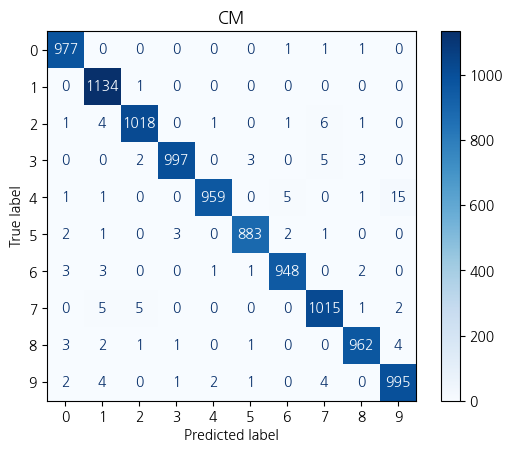

In [91]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('CM')
plt.show()

In [92]:
def show_predictions(dataset, y_pred, y_prob, n=12):
    plt.figure(figsize=(14, 4))

    for i in range(n):
        image, label = dataset[i]
        image_for_plot = denormalize(image).squeeze(0)

        pred_label = y_pred[i]
        confidence = y_prob[i, pred_label]

        plt.subplot(2, 6, i+1)
        plt.imshow(image_for_plot, cmap='gray')
        plt.title(f'True: {label}, Pred: {pred_label}\nConf: {confidence:.3f}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

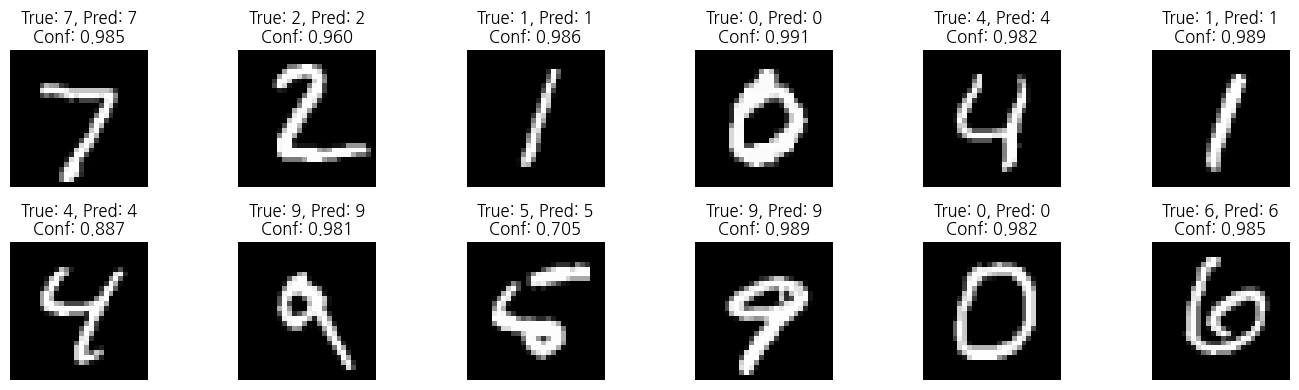

In [93]:
show_predictions(test_dataset, y_pred, y_prob, n=12)

In [94]:
wrong_indices = np.where(y_pred != y_true)[0]
print(f'틀린 개수: {len(wrong_indices)}')

틀린 개수: 112


In [95]:
def show_misclassified(dataset, wrong_indices, y_pred, y_prob, n=12):
    if len(wrong_indices) == 0:
        print('오분류 이미지 없음')
        return

    n = min(n, len(wrong_indices))

    plt.figure(figsize=(14, 4))
    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]
        image, label = dataset[data_idx]
        image_for_plot = denormalize(image).squeeze(0)

        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]

        plt.subplot(2, 6, plot_idx + 1)
        plt.imshow(image_for_plot, cmap='gray')
        plt.title(f'True: {label}, Pred: {pred_label}\nConf: {confidence:.3f}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

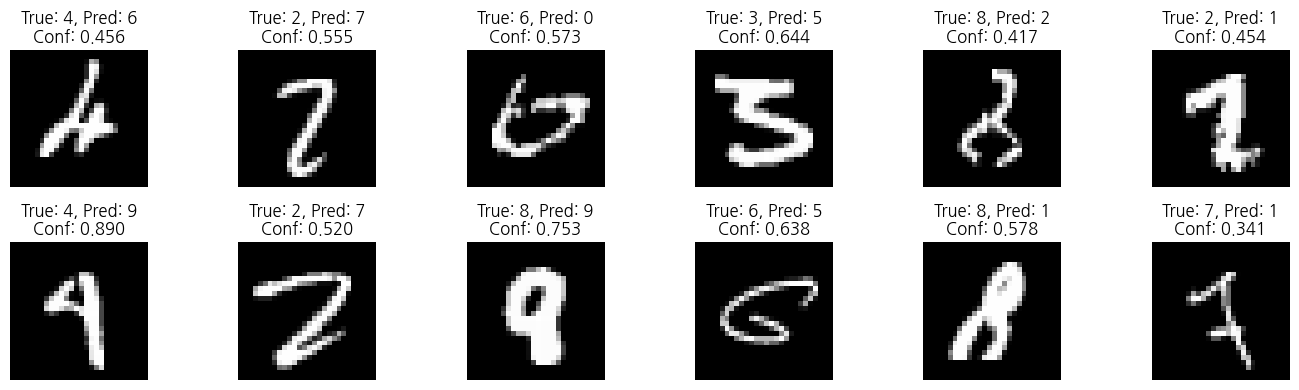

In [96]:
show_misclassified(test_dataset, wrong_indices, y_pred, y_prob, n=12)

In [97]:
def show_misclassified_active(dataset, wrong_indices, y_pred, y_prob, n=12):
    if len(wrong_indices) == 0:
        print('오분류 이미지 없음')
        return

    n = min(n, len(wrong_indices))

    cols = min(6, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize = (cols * 2.3, rows * 3)
    )

    axes = np.array(axes).reshape(-1)
    
    for plot_idx in range(n):
        data_idx = wrong_indices[plot_idx]
        
        image, label = dataset[data_idx]
        image_for_plot = denormalize(image).squeeze(0).cpu().numpy()

        pred_label = y_pred[data_idx]
        confidence = y_prob[data_idx, pred_label]

        axes[plot_idx].imshow(image_for_plot, cmap='gray')
        axes[plot_idx].set_title(f'True: {label}, Pred: {pred_label}\nConf: {confidence:.2f}')
        axes[plot_idx].axis('off')

    for empty_idx in range(n, len(axes)):
        axes[empty_idx].axis('off')

    plt.tight_layout()
    plt.show()

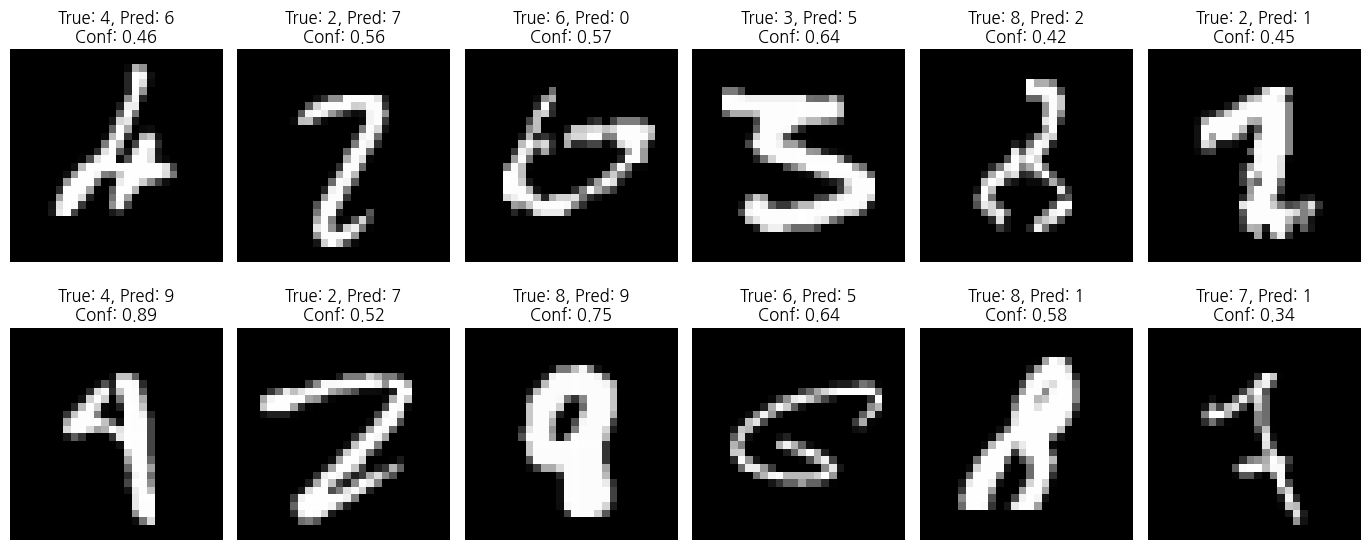

In [98]:
show_misclassified_active(test_dataset, wrong_indices, y_pred, y_prob, n=12)

In [99]:
def predict_one_image(model, dataset, index, device):
    model.eval()

    image, true_label = dataset[index]
    input_image = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_image)
        probability = torch.softmax(output, dim=1)
        pred_label = probability.argmax(dim=1).item()
        confidence = probability[0, pred_label].item()

    plt.figure(figsize=(3, 3))
    plt.imshow(denormalize(image[0]), cmap='gray')
    plt.title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2f}')
    plt.axis('off')
    plt.show()
    
    return pred_label, confidence


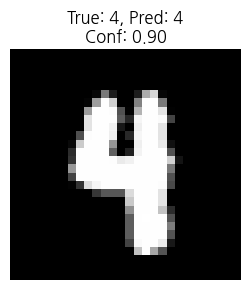

(4, 0.9019162058830261)

In [100]:
predict_one_image(model, test_dataset, index=250, device=device)